In [1]:
### 1) Desactivar GPU y cargar librerías
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, multilabel_confusion_matrix, accuracy_score
)
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow.keras.backend as K


In [3]:
### 2) Cargar dataset de keypoints y etiquetas (por frame)
keypoints_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/csv/keypoints_final_unilado_640.csv'
)
labels_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/csv/etiquetas_por_frame.csv'
)

keypoints_data['video_filename'] = keypoints_data['video_filename'].str.strip()
labels_data['video'] = labels_data['video'].str.strip()

print("✅ Datos cargados:")
print("Keypoints:", keypoints_data.shape)
print("Labels:", labels_data.shape)

✅ Datos cargados:
Keypoints: (2213079, 7)
Labels: (67063, 8)


In [4]:
### 3) Configurar columnas de landmarks y etiquetas
landmarks_to_keep = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

error_cols = [
    'giro_incompleto',
    'pierna_patea_flexionada',
    'pierna_base_flexionada',
    'pie_sin_borde_externo',
    'preparacion_incompleta',
    'recogida_incompleta'
]
print("Etiquetas:", error_cols)


Etiquetas: ['giro_incompleto', 'pierna_patea_flexionada', 'pierna_base_flexionada', 'pie_sin_borde_externo', 'preparacion_incompleta', 'recogida_incompleta']


In [5]:
### 4) Funciones auxiliares
def angle(a, b, c):
    ba = a - b
    bc = c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))


In [7]:
### 5) Reconstruir secuencias y sincronizar con etiquetas frame a frame
video_frames = {}
video_labels = {}

for (video, frame), group in keypoints_data.groupby(['video_filename', 'frame']):
    group_sorted = group.sort_values(by='landmark_index')
    group_sorted = group_sorted[group_sorted['landmark_index'].isin(landmarks_to_keep)]
    pts = group_sorted[['x','y','z']].values
    vis = group_sorted['visibility'].values[:, None]
    frame_vec = np.hstack([pts, vis]).flatten()

    idx = {lm:i for i,lm in enumerate(landmarks_to_keep)}
    L_HIP,R_HIP = pts[idx[23]], pts[idx[24]]
    L_KNEE,R_KNEE = pts[idx[25]], pts[idx[26]]
    L_ANK,R_ANK  = pts[idx[27]], pts[idx[28]]
    L_HEEL,R_HEEL= pts[idx[29]], pts[idx[30]]
    L_FI,R_FI    = pts[idx[31]], pts[idx[32]]

    ang_knee_L  = angle(L_HIP,L_KNEE,L_ANK)
    ang_knee_R  = angle(R_HIP,R_KNEE,R_ANK)
    ang_ankle_L = angle(L_KNEE,L_ANK,L_HEEL)
    ang_ankle_R = angle(R_KNEE,R_ANK,R_HEEL)

    dir_foot_L = (L_FI - L_HEEL)/(np.linalg.norm(L_FI - L_HEEL)+1e-8)
    dir_foot_R = (R_FI - R_HEEL)/(np.linalg.norm(R_FI - R_HEEL)+1e-8)

    extras = np.hstack([[ang_knee_L, ang_knee_R, ang_ankle_L, ang_ankle_R], dir_foot_L, dir_foot_R])
    feature_vec = np.concatenate([frame_vec, extras])

    video_frames.setdefault(video, []).append(feature_vec)

    # Buscar etiquetas para este frame
    label_row = labels_data[
        (labels_data['video'] == video) & (labels_data['frame'] == frame)
    ]
    if len(label_row) == 1:
        video_labels.setdefault(video, []).append(label_row[error_cols].values[0])
    else:
        video_labels.setdefault(video, []).append(np.zeros(len(error_cols)))

fixed_frame_count = max(len(v) for v in video_frames.values())
frame_dim = len(landmarks_to_keep)*4 + 10
print(f"Frames fijos: {fixed_frame_count}, features/frame: {frame_dim}")


Frames fijos: 162, features/frame: 50


In [8]:
### 6) Padding y armado de X, y
def pad_sequence(seq, max_len, pad_value=0.0):
    pad_size = max_len - len(seq)
    if pad_size <= 0:
        return np.array(seq[:max_len])
    pad = np.full((pad_size, seq[0].shape[-1]), pad_value)
    return np.vstack([seq, pad])

X_list, y_list, video_names = [], [], []
for video in video_frames.keys():
    X_video = pad_sequence(np.array(video_frames[video]), fixed_frame_count)
    y_video = pad_sequence(np.array(video_labels[video]), fixed_frame_count)
    X_list.append(X_video)
    y_list.append(y_video)
    video_names.append(video)

X = np.array(X_list, dtype='float32')
y = np.array(y_list, dtype='float32')

print("✅ Datos preparados:")
print("X.shape:", X.shape)
print("y.shape:", y.shape)


✅ Datos preparados:
X.shape: (640, 162, 50)
y.shape: (640, 162, 6)


In [9]:
### 7) Train/Val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "X_val:", X_val.shape)


X_train: (512, 162, 50) X_val: (128, 162, 50)


In [10]:
### 8) Escalado preservando padding
def scale_preserving_padding(X_split):
    ns, nf, nd = X_split.shape
    X_flat = X_split.reshape(-1, nd)
    zero_rows = np.all(X_flat == 0.0, axis=1)
    scaler = StandardScaler()
    non_zero_idx = np.where(~zero_rows)[0]
    scaler.fit(X_flat[non_zero_idx])
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled_flat[zero_rows] = 0.0
    return X_scaled_flat.reshape(ns, nf, nd), scaler

X_train_scaled, scaler = scale_preserving_padding(X_train)
X_val_scaled, _ = scale_preserving_padding(X_val)


In [ ]:
### 9) Modelo BiLSTM frame a frame
num_frames, num_features, num_labels = X_train.shape[1], X_train.shape[2], y_train.shape[2]

input_seq = Input(shape=(num_frames, num_features))
mask = layers.Masking(mask_value=0.0)(input_seq)

x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3), recurrent_dropout=0.3))(mask)
x = layers.Dropout(0.5)(x)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)))(x)
x = layers.Dropout(0.5)(x)
x = layers.TimeDistributed(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3)))(x)
x = layers.Dropout(0.5)(x)
output = layers.TimeDistributed(layers.Dense(num_labels, activation='sigmoid'))(x)

model = Model(input_seq, output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['bin_acc'])
model.summary()




Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 162, 50)]         0         
                                                                 
 masking (Masking)           (None, 162, 50)           0         
                                                                 
 bidirectional (Bidirection  (None, 162, 512)          628736    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 162, 512)          0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 162, 256)          656384    
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 162, 256)          0   

In [12]:
### 10) Entrenamiento
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_frames.h5', save_best_only=True, monitor='val_loss', verbose=1)
]

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=4,
    callbacks=callbacks, verbose=2
)


Epoch 1/100



Epoch 1: val_loss improved from inf to 0.15059, saving model to best_model_frames.h5
128/128 - 32s - loss: 0.5287 - accuracy: 0.2140 - val_loss: 0.1506 - val_accuracy: 0.1197 - 32s/epoch - 248ms/step
Epoch 2/100


c:\Users\user\miniconda3\envs\tesis\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 0.15059 to 0.08403, saving model to best_model_frames.h5
128/128 - 21s - loss: 0.1130 - accuracy: 0.2054 - val_loss: 0.0840 - val_accuracy: 0.1229 - 21s/epoch - 161ms/step
Epoch 3/100

Epoch 3: val_loss improved from 0.08403 to 0.06972, saving model to best_model_frames.h5
128/128 - 24s - loss: 0.0792 - accuracy: 0.1925 - val_loss: 0.0697 - val_accuracy: 0.1007 - 24s/epoch - 187ms/step
Epoch 4/100

Epoch 4: val_loss did not improve from 0.06972
128/128 - 20s - loss: 0.0692 - accuracy: 0.1935 - val_loss: 0.0718 - val_accuracy: 0.1003 - 20s/epoch - 157ms/step
Epoch 5/100

Epoch 5: val_loss improved from 0.06972 to 0.06393, saving model to best_model_frames.h5
128/128 - 20s - loss: 0.0637 - accuracy: 0.2022 - val_loss: 0.0639 - val_accuracy: 0.1126 - 20s/epoch - 157ms/step
Epoch 6/100

Epoch 6: val_loss did not improve from 0.06393
128/128 - 19s - loss: 0.0616 - accuracy: 0.2219 - val_loss: 0.0670 - val_accuracy: 0.0854 - 19s/epoch - 151ms/step
Epoch 7/100

In [13]:
### 11) Evaluación global
y_pred_prob = model.predict(X_val_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Reporte de clasificación (frame a frame):")
for i, label in enumerate(error_cols):
    print(f"\nEtiqueta: {label}")
    print(classification_report(y_val[:,:,i].flatten(), y_pred[:,:,i].flatten(), zero_division=0))


4/4 [==============================] - 3s 93ms/step
Reporte de clasificación (frame a frame):

Etiqueta: giro_incompleto
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     20410
         1.0       0.73      0.25      0.38       326

    accuracy                           0.99     20736
   macro avg       0.86      0.63      0.69     20736
weighted avg       0.98      0.99      0.98     20736


Etiqueta: pierna_patea_flexionada
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     20492
         1.0       0.53      0.50      0.52       244

    accuracy                           0.99     20736
   macro avg       0.76      0.75      0.76     20736
weighted avg       0.99      0.99      0.99     20736


Etiqueta: pierna_base_flexionada
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     20526
         1.0       0.45      0.58      0.51    

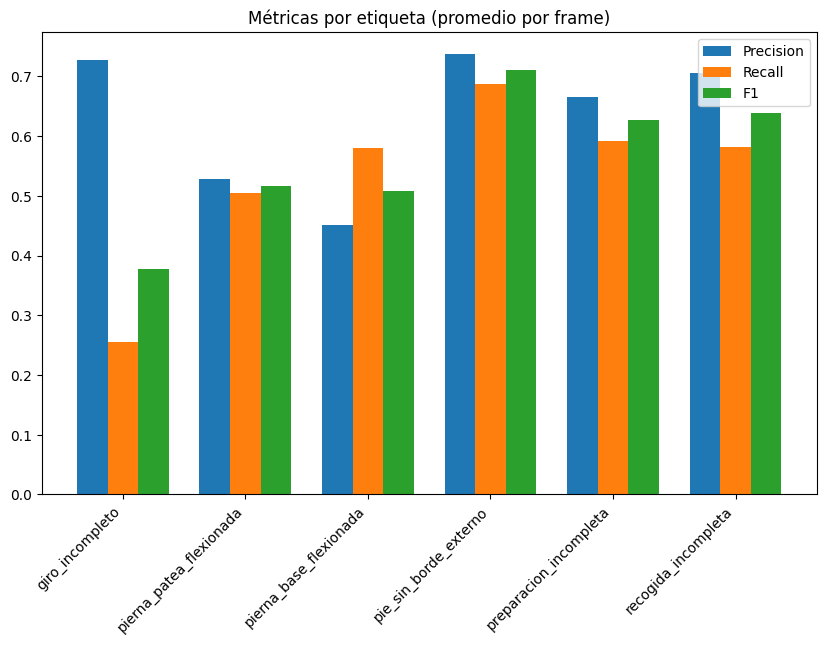

In [14]:
precisions = []
recalls = []
f1s = []

for i, label in enumerate(error_cols):
    y_true = y_val[:,:,i].flatten()
    y_pred_flat = y_pred[:,:,i].flatten()
    precisions.append(precision_score(y_true, y_pred_flat, zero_division=0))
    recalls.append(recall_score(y_true, y_pred_flat, zero_division=0))
    f1s.append(f1_score(y_true, y_pred_flat, zero_division=0))

x = np.arange(len(error_cols))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, precisions, width, label='Precision')
plt.bar(x, recalls, width, label='Recall')
plt.bar(x + width, f1s, width, label='F1')
plt.xticks(x, error_cols, rotation=45, ha='right')
plt.legend()
plt.title('Métricas por etiqueta (promedio por frame)')
plt.show()


In [ ]:
### 13) Guardar modelo entrenado
model.save("modelo_lstm_frames.keras")
print("✅ Modelo guardado correctamente.")


✅ Modelo guardado correctamente.


c:\Users\user\miniconda3\envs\tesis\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 